<a href="https://colab.research.google.com/github/sujay3112006/Data-Sciences-SAT/blob/main/Student_academic_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

attendance_category
Low       62.882609
Medium    63.922857
High      67.096774
Name: final_exam_marks, dtype: float64
study_group
Low       59.423529
Medium    58.790000
High      68.163855
Name: final_exam_marks, dtype: float64


/tmp/ipykernel_530/843105268.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("attendance_category")["final_exam_marks"].mean())
/tmp/ipykernel_530/843105268.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("study_group")["final_exam_marks"].mean())


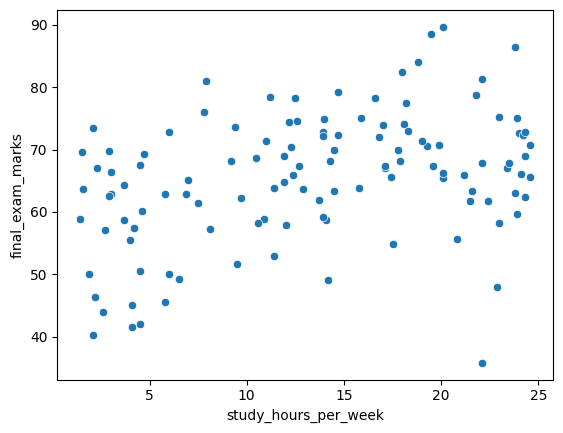

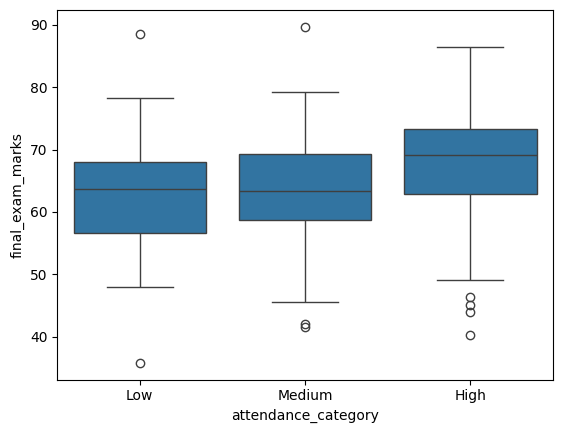

attendance_percent      0.189567
assignment_score        0.210388
internal_marks          0.449891
study_hours_per_week    0.383518
final_exam_marks        1.000000
Name: final_exam_marks, dtype: float64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Q37_student_performance.csv")

df["assignment_score"] = df["assignment_score"].fillna(df["assignment_score"].median())
df["study_hours_per_week"] = df["study_hours_per_week"].fillna(df["study_hours_per_week"].median())
df = df.drop_duplicates()

df.loc[(df["attendance_percent"] < 0) | (df["attendance_percent"] > 100),
       "attendance_percent"] = df["attendance_percent"].median()

df["internal_average"] = (df["assignment_score"] + df["internal_marks"]) / 2

df["attendance_category"] = pd.cut(
    df["attendance_percent"],
    bins=[-1, 59, 74, 100],
    labels=["Low", "Medium", "High"]
)

df["study_group"] = pd.cut(
    df["study_hours_per_week"],
    bins=[-1, 4, 9, 100],
    labels=["Low", "Medium", "High"]
)

print(df.groupby("attendance_category")["final_exam_marks"].mean())
print(df.groupby("study_group")["final_exam_marks"].mean())

sns.scatterplot(data=df, x="study_hours_per_week", y="final_exam_marks")
plt.show()

sns.boxplot(data=df, x="attendance_category", y="final_exam_marks")
plt.show()

print(df[[
    "attendance_percent", "assignment_score", "internal_marks",
    "study_hours_per_week", "final_exam_marks"
]].corr()["final_exam_marks"])

df.to_csv("cleaned_data.csv", index=False)